# V55: Pro Smart Stability (Momentum Sorted MIS) (LQ45)

Notebook ini adalah evolusi dari V54 dan V53, menggabungkan kestabilan dengan performa tinggi.

### Masalah Sebelumnya:
- **V54 (Stable):** Stabil tapi hasil rendah karena seleksi aset berdasarkan **Abjad (A-Z)**. Bias negatif jika saham 'A' jelek tapi dipilih karena urutan.
- **V53 (Random):** Hasil bagus tapi **Tidak Stabil (Acak)**. Sulit direproduksi.

### Solusi V55 (Smart Selection):
Strategi ini menggunakan **Momentum Sorting** sebelum seleksi korelasi (MIS).
1. Hitung Momentum (Rata-rata Return) semua aset di window berjalan.
2. Urutkan aset dari **Momentum Tertinggi ke Terendah**.
3. Jalankan algoritma MIS pada urutan tersebut.

**Hasil:** Jika ada dua saham berkorelasi tinggi (konflik), algoritma akan secara deterministik memilih saham dengan **Momentum Lebih Tinggi**.

### Fitur Lain:
- **AI + Trend Override:** Tetap menggunakan AI Signal dengan paksaan Hold jika tren Bullish (SMA 50).
- **Reproducible:** Random Seed dikunci (42), hasil dijamin sama setiap run.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import fbeta_score
import random
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- LOCK RANDOMNESS FOR STABILITY ---
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# --- 1. Load Data ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
# Reconstruct Market Index for Trend Calculation
market_index = (1 + market_return).cumprod() * 100

print(f"Data Loaded: {len(data)} rows")

Data Loaded: 712 rows


In [2]:
# --- 2. AI Training (Standard V47) ---
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
X_test = features.loc[features.index.year == 2025]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=SEED, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
opt_t = np.linspace(0.3, 0.7, 41)[np.argmax([fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) for t in np.linspace(0.3, 0.7, 41)])]
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimized Threshold: {opt_t:.2f}")

Optimized Threshold: 0.54


In [3]:
# --- 3. Core Logic: Smart Momentum Selection ---

def get_mis_assets_smart(returns_window, correlation_threshold=0.4):
    """
    Selects assets with Low Correlation, prioritizing High Momentum assets.
    V55 Innovation: Sorts by Mean Return (Desc) before graph construction.
    """
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    # --- SMART SORTING ---
    # Calculate momentum (mean return over the window)
    momentum = returns_window.mean()
    # Sort assets: Highest momentum first
    assets = list(momentum.sort_values(ascending=False).index)
    
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    
    # nx.approximation.maximum_independent_set generally respects input order in heuristic
    # This prioritizes keeping nodes from the start of the list (High Momentum)
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    num_assets = len(mu)

    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = [1./num_assets] * num_assets

    res = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_simulation_smart(test_dates, returns, ai_probs, threshold, market_idx, 
                          override_ma=None, # e.g., 50 for Trend Override
                          fee=0.0025, 
                          g_lookback=60, 
                          rebal_period=20, 
                          turnover_buffer=0.05):
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    
    current_weights = {} 
    risk_status = False 
    
    days_since_rebal = 999
    
    # Calculate Moving Average for Trend Override check
    market_ma = None
    if override_ma:
        market_ma = market_idx.rolling(window=override_ma).mean()
    
    for i, date in enumerate(test_dates[:-1]):
        prev_risk_status = risk_status
        prob = ai_probs.loc[date]
        
        # 1. Base AI Signal
        ai_signal = False
        buffer = 0.05
        if not risk_status and prob > (threshold + buffer): ai_signal = True
        elif risk_status and prob < (threshold - buffer): ai_signal = False
        else: ai_signal = risk_status 
        
        # 2. Trend Override Logic
        final_signal = ai_signal
        
        if override_ma and market_ma is not None:
            try:
                current_price = market_idx.loc[date]
                ma_price = market_ma.loc[date]
                if not pd.isna(ma_price) and not pd.isna(current_price):
                    is_uptrend = (current_price > ma_price)
                    if ai_signal == False and is_uptrend:
                        final_signal = True # Force Hold
            except KeyError:
                pass 
        
        risk_status = final_signal
        regime_changed = (risk_status != prev_risk_status)
        
        # --- 3. Portfolio Management ---
        target_weights = current_weights.copy()
        
        if not risk_status:
            # Risk OFF
            if regime_changed or 'CASH' not in current_weights or current_weights.get('CASH', 0) < 0.99:
                target_weights = {'CASH': 1.0}
                days_since_rebal = 0
        else:
            # Risk ON
            if regime_changed or days_since_rebal >= rebal_period:
                loc_idx = returns.index.get_loc(date)
                window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
                # USE SMART SELECTION HERE
                selected = get_mis_assets_smart(window_rets)
                optimized_weights = optimize_markowitz(window_rets[selected])
                
                all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
                turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
                
                if regime_changed or turnover_est > turnover_buffer:
                    target_weights = optimized_weights
                    days_since_rebal = 0
            
            days_since_rebal += 1

        # --- 4. Execution ---
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        
        if turnover_actual > 0.001:
            cost = val * turnover_actual * fee
            val -= cost
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights_drifted = {}
        
        if 'CASH' in target_weights and target_weights['CASH'] > 0.99:
            day_ret = 0
            new_weights_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                if asset in returns.columns:
                    r = returns.loc[next_date, asset]
                    r_asset = r if not pd.isna(r) else 0
                    day_ret += w * r_asset
                    new_weights_drifted[asset] = w * (1 + r_asset)
                else:
                    new_weights_drifted[asset] = w
            
            total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
            if total_w > 0:
                new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

Running Static (Full Invest) with Smart Selection...
Running V55 Pro (AI + Trend Override SMA 50 + Smart Selection)...


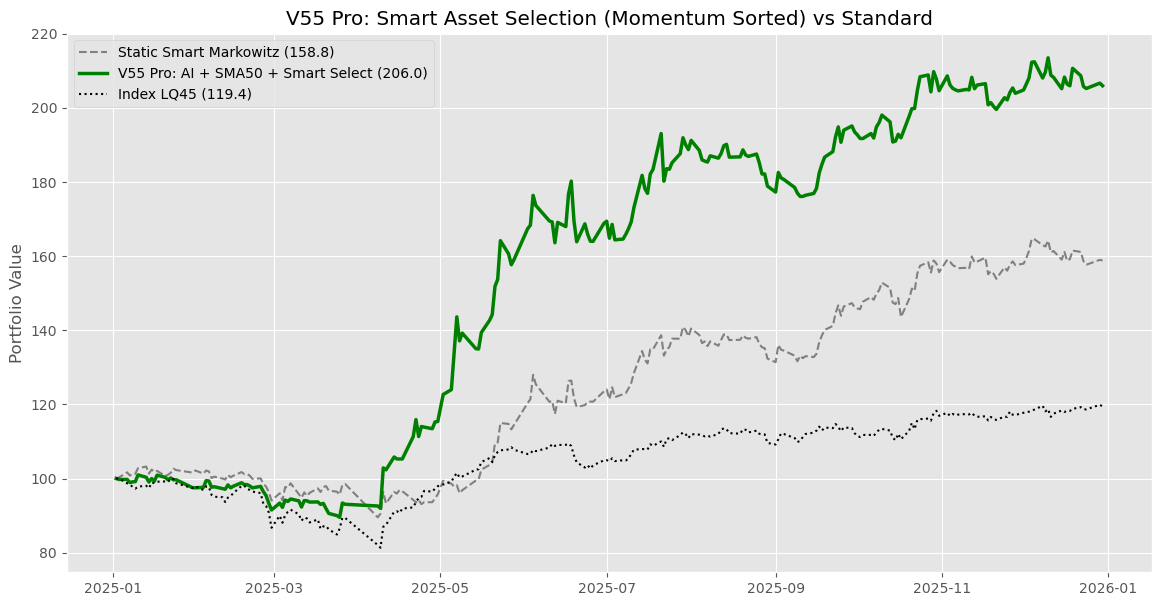

In [4]:
# --- 4. Running Simulations ---

print("Running Static (Full Invest) with Smart Selection...")
# Ensure Static strategy also benefits from Smart Selection for fair comparison
static_sim = run_simulation_smart(test_dates=X_test.index, returns=returns, ai_probs=test_probs, threshold=-1.0, market_idx=market_index, override_ma=None)

print("Running V55 Pro (AI + Trend Override SMA 50 + Smart Selection)...")
v55_sim = run_simulation_smart(test_dates=X_test.index, returns=returns, ai_probs=test_probs, threshold=opt_t, market_idx=market_index, override_ma=50)

# Compare with Index
lq45_idx = market_index.loc[X_test.index] / market_index.loc[X_test.index[0]] * 100

# --- 5. Visualization ---
plt.figure(figsize=(14, 7))
plt.plot(static_sim.index, static_sim['Portfolio_Value'], label=f'Static Smart Markowitz ({static_sim.iloc[-1].values[0]:.1f})', linestyle='--', color='gray')
plt.plot(v55_sim.index, v55_sim['Portfolio_Value'], label=f'V55 Pro: AI + SMA50 + Smart Select ({v55_sim.iloc[-1].values[0]:.1f})', linewidth=2.5, color='green')
plt.plot(lq45_idx.index, lq45_idx, label=f'Index LQ45 ({lq45_idx.iloc[-1]:.1f})', linestyle=':', color='black')

plt.title('V55 Pro: Smart Asset Selection (Momentum Sorted) vs Standard')
plt.ylabel('Portfolio Value')
plt.legend()
plt.show()